# Naive Bayes Spam Classification

This notebook trains a Multinomial Naive Bayes model to classify SMS messages as **ham** or **spam**.

The model expects `spam.csv` with these columns:

- `v1`: message label (`ham` or `spam`)
- `v2`: message text

The notebook searches common repository locations so it can be run from either the project root or this notebook's folder.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB


# Support running from the repository root, the Machine-Learning-Lab folder,
# or the notebooks folder in VS Code.
def find_dataset(filename="spam.csv"):
    search_locations = (
        Path.cwd() / filename,
        Path.cwd() / "data" / filename,
        Path.cwd().parent / "data" / filename,
    )

    for candidate in search_locations:
        if candidate.is_file():
            return candidate

    searched_paths = "\n".join(f"- {path}" for path in search_locations)
    raise FileNotFoundError(
        f"Could not find {filename}. Searched these locations:\n{searched_paths}"
    )


dataset_path = find_dataset()
print(f"Using dataset: {dataset_path.resolve()}")

c:\Users\Lenovo\OneDrive\Documents\Jupyter\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Lenovo\OneDrive\Documents\Jupyter\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Using dataset: C:\Users\Lenovo\OneDrive\Desktop\data-science-playground\data-science-playground\data-science-playground\Machine-Learning-Lab\data\spam.csv


In [2]:
# Load only the label and message columns used by the classifier.
data = pd.read_csv(dataset_path, encoding="latin-1")
required_columns = {"v1", "v2"}
missing_columns = required_columns.difference(data.columns)

if missing_columns:
    raise ValueError(
        f"The dataset is missing required columns: {sorted(missing_columns)}"
    )

data = data[["v1", "v2"]].rename(columns={"v1": "label", "v2": "message"})
data = data.dropna(subset=["label", "message"])

print(f"Loaded {len(data):,} messages.")
print("Labels:", ", ".join(sorted(data["label"].unique())))
data.head()

Loaded 5,572 messages.
Labels: ham, spam


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# Convert message text into a matrix of word-count features.
vectorizer = CountVectorizer()
features = vectorizer.fit_transform(data["message"])
target = data["label"]

# Keep the test set separate so evaluation measures performance on unseen messages.
features_train, features_test, target_train, target_test = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=0,
    stratify=target,
)

model = MultinomialNB()
model.fit(features_train, target_train)

predictions = model.predict(features_test)
metrics = {
    "Accuracy": accuracy_score(target_test, predictions),
    "Precision (spam)": precision_score(
        target_test, predictions, pos_label="spam", zero_division=0
    ),
    "Recall (spam)": recall_score(
        target_test, predictions, pos_label="spam", zero_division=0
    ),
}

for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {metric_value:.3f}")

Accuracy: 0.982
Precision (spam): 0.939
Recall (spam): 0.926


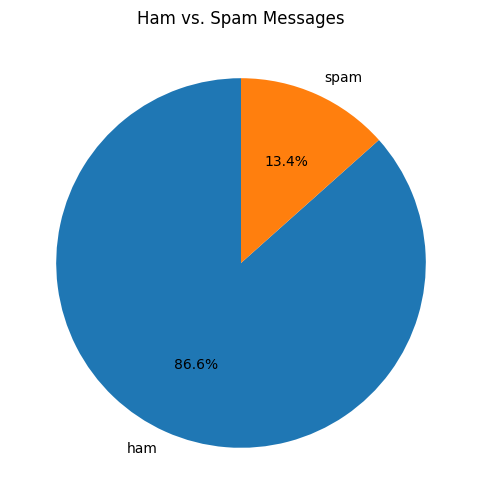

In [4]:
# Visualize the class balance in the dataset.
label_counts = data["label"].value_counts().reindex(["ham", "spam"])

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(label_counts, labels=label_counts.index, autopct="%1.1f%%", startangle=90)
ax.set_title("Ham vs. Spam Messages")
plt.show()

In [5]:
# Try the trained classifier on a new message.
new_message = "You won a free prize"
new_message_features = vectorizer.transform([new_message])
predicted_label = model.predict(new_message_features)[0]

print(f"Message: {new_message}")
print(f"Prediction: {predicted_label}")

Message: You won a free prize
Prediction: spam
